# 06 — Build plot data and R figures

Notebook 06 creates standardized plot data and the R figures.

Outputs are separated:
- generated plot tables: `data/plot_data/<run_id>/`
- all PNGs from notebooks 06 and 07: `data/figures/<run_id>/`

Notebook 07 reuses the same `<run_id>`, so every plot from both notebooks lands
in one figure directory.

Analysis conventions:
- Finland and Estonia are pooled as `FIN/EST` versus `RUS`
- TEMPTED dimensions are components; MEFISTO dimensions are factors
- no pseudocount is introduced


In [1]:
suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(tidyr)
})

SELECTED_BATCH <- ""
TOP_FEATURES <- 12

LABEL_MAP <- c(
  FIN = "FIN/EST",
  FINLAND = "FIN/EST",
  EST = "FIN/EST",
  ESTONIA = "FIN/EST",
  RUS = "RUS",
  RUSSIA = "RUS"
)
GROUP_ORDER <- c("FIN/EST", "RUS")
GROUP_COLORS <- c("FIN/EST" = "#0072E8", "RUS" = "#F03B20")

normalize_group <- function(x) {
  key <- toupper(trimws(as.character(x)))
  out <- LABEL_MAP[key]
  out[is.na(out)] <- trimws(as.character(x))[is.na(out)]
  out
}

root <- if (dir.exists("data")) "." else ".."

newest_complete_run <- function(folder, required_files) {
  runs <- sort(list.dirs(folder, recursive = FALSE), decreasing = TRUE)
  for (run in runs) {
    if (all(file.exists(file.path(run, required_files)))) return(run)
  }
  stop(paste("No complete run found in", folder))
}

newest_complete_split <- function(folder) {
  runs <- sort(list.dirs(folder, recursive = FALSE), decreasing = TRUE)
  for (run in runs) {
    batches <- list.dirs(run, recursive = FALSE)
    batches <- batches[grepl("^batch_", basename(batches))]
    if (length(batches) && all(file.exists(file.path(batches, "train_rclr.csv.gz")))) return(run)
  }
  stop("No complete split run found")
}

read_table <- function(path) {
  if (grepl("\\.gz$", path)) read.csv(gzfile(path), check.names = FALSE) else read.csv(path, check.names = FALSE)
}

find_table <- function(folder, stem) {
  paths <- c(
    file.path(folder, paste0(stem, ".csv.gz")),
    file.path(folder, paste0(stem, ".csv"))
  )
  existing <- paths[file.exists(paths)]
  if (length(existing)) existing[1] else NA_character_
}

read_matrix_table <- function(folder, stem) {
  path <- find_table(folder, stem)
  if (is.na(path)) return(NULL)
  x <- read_table(path)
  rownames(x) <- as.character(x$sample_id)
  x$sample_id <- NULL
  as.matrix(x)
}

splits_run <- newest_complete_split(file.path(root, "data", "splits"))
tempted_run <- newest_complete_run(
  file.path(root, "data", "tempted"),
  c("all_metrics.csv", "all_predictions.csv.gz")
)
mefisto_run <- newest_complete_run(
  file.path(root, "data", "mefisto"),
  c("all_metrics.csv", "all_predictions.csv.gz")
)

batch_names <- Reduce(
  intersect,
  list(
    basename(list.dirs(splits_run, recursive = FALSE)),
    basename(list.dirs(tempted_run, recursive = FALSE)),
    basename(list.dirs(mefisto_run, recursive = FALSE))
  )
)
batch_names <- sort(batch_names[grepl("^batch_", batch_names)])
batch <- if (nzchar(SELECTED_BATCH)) SELECTED_BATCH else batch_names[1]

split_batch <- file.path(splits_run, batch)
tempted_batch <- file.path(tempted_run, batch)
mefisto_batch <- file.path(mefisto_run, batch)

run_id <- format(Sys.time(), "%Y%m%d_%H%M%S")
data_output <- file.path(root, "data", "plot_data", run_id)
figure_output <- file.path(root, "data", "figures", run_id)
dir.create(data_output, recursive = TRUE)
dir.create(figure_output, recursive = TRUE)

cat(
  "Split:", splits_run,
  "\nTEMPTED:", tempted_run,
  "\nMEFISTO:", mefisto_run,
  "\nBatch:", batch,
  "\nPlot data:", data_output,
  "\nFigures:", figure_output, "\n"
)

Split: ../data/splits/20260806_210520 
TEMPTED: ../data/tempted/20260806_210539 
MEFISTO: ../data/mefisto/20260805_234330 
Batch: batch_001 
Plot data: ../data/plot_data/20260807_032009 
Figures: ../data/figures/20260807_032009 


In [2]:
train_counts <- read_table(find_table(split_batch, "train_counts"))
test_counts <- read_table(find_table(split_batch, "test_counts"))
train_meta <- read_table(find_table(split_batch, "train_metadata"))
test_meta <- read_table(find_table(split_batch, "test_metadata"))

counts <- bind_rows(train_counts, test_counts)
metadata <- bind_rows(train_meta, test_meta) %>%
  mutate(
    sample_id = as.character(sample_id),
    subject_id = as.character(subject_id),
    label = factor(normalize_group(label), levels = GROUP_ORDER),
    time = as.numeric(time)
  )

rownames(counts) <- as.character(counts$sample_id)
counts$sample_id <- NULL
counts <- as.matrix(counts[metadata$sample_id, , drop = FALSE])
storage.mode(counts) <- "numeric"

train_rclr <- read_matrix_table(split_batch, "train_rclr")
test_rclr <- read_matrix_table(split_batch, "test_rclr")
tempted_values <- rbind(train_rclr, test_rclr)
tempted_values <- tempted_values[metadata$sample_id, , drop = FALSE]

load_loadings <- function(method, folder) {
  path <- find_table(folder, "feature_loadings")

  if (!is.na(path)) {
    x <- read_table(path)
    names(x)[1] <- "feature_id"
    return(x)
  }

  saved <- readRDS(file.path(folder, "model.rds"))
  model <- saved$model
  B <- model$B_hat
  if (is.null(B)) B <- model$b_hat
  if (is.null(B)) B <- model$B

  B <- as.matrix(B)
  if (nrow(B) < ncol(B)) B <- t(B)

  feature_ids <- rownames(B)
  if (is.null(feature_ids)) feature_ids <- colnames(counts)[seq_len(nrow(B))]

  x <- data.frame(feature_id = feature_ids, B, check.names = FALSE)
  names(x)[-1] <- paste0("factor_", seq_len(ncol(B)))
  x
}

load_subject_scores <- function(folder) {
  x <- read_table(find_table(folder, "test_subject_scores"))
  factors <- grep("^factor_[0-9]+$", names(x), value = TRUE)
  if (!length(factors)) {
    means <- grep("^factor_[0-9]+_mean$", names(x), value = TRUE)
    names(x)[match(means, names(x))] <- sub("_mean$", "", means)
    factors <- sub("_mean$", "", means)
  }
  x %>%
    mutate(subject_id = as.character(subject_id),
           label = factor(normalize_group(label), levels = GROUP_ORDER)) %>%
    select(subject_id, label, all_of(factors))
}

tempted_loadings <- load_loadings("TEMPTED", tempted_batch)
mefisto_loadings <- load_loadings("MEFISTO", mefisto_batch)

tempted_scores <- load_subject_scores(tempted_batch) %>% mutate(method = "TEMPTED")
mefisto_scores <- load_subject_scores(mefisto_batch) %>% mutate(method = "MEFISTO")
subject_scores <- bind_rows(tempted_scores, mefisto_scores)

project_tempted_samples <- function(loadings) {
  factors <- grep("^factor_", names(loadings), value = TRUE)
  shared <- intersect(loadings$feature_id, colnames(tempted_values))
  W <- as.matrix(loadings[match(shared, loadings$feature_id), factors, drop = FALSE])
  X <- tempted_values[, shared, drop = FALSE]
  projected <- X %*% W

  data.frame(sample_id = metadata$sample_id, projected, check.names = FALSE) %>%
    bind_cols(metadata %>% select(subject_id, time, label)) %>%
    mutate(method = "TEMPTED")
}

load_mefisto_samples <- function(folder) {
  train <- read_table(find_table(folder, "train_sample_factors"))
  test <- read_table(find_table(folder, "test_sample_factors"))
  bind_rows(train, test) %>%
    mutate(
      sample_id = as.character(sample_id),
      subject_id = as.character(subject_id),
      time = as.numeric(time),
      label = factor(normalize_group(label), levels = GROUP_ORDER),
      method = "MEFISTO"
    ) %>%
    select(sample_id, starts_with("factor_"), subject_id, time, label, method)
}

sample_factors <- bind_rows(
  project_tempted_samples(tempted_loadings),
  load_mefisto_samples(mefisto_batch)
)

feature_loadings <- bind_rows(
  tempted_loadings %>% mutate(method = "TEMPTED"),
  mefisto_loadings %>% mutate(method = "MEFISTO")
)

Warning message:
“Removed 189 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 189 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


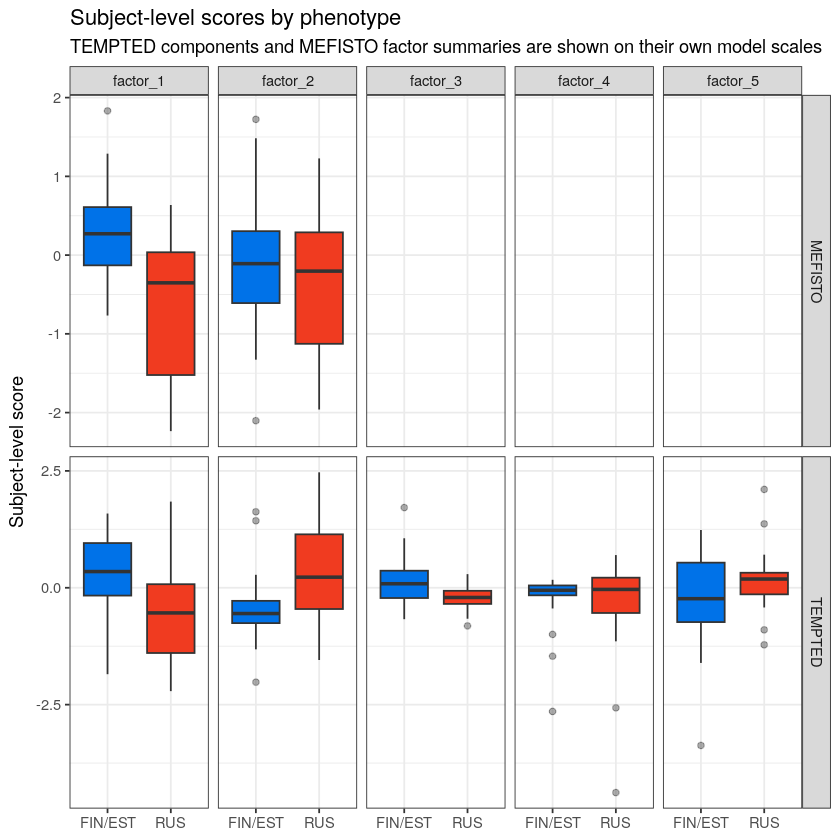

Warning message:
“Removed 36 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 36 rows containing missing values or values outside the scale range
(`geom_col()`).”


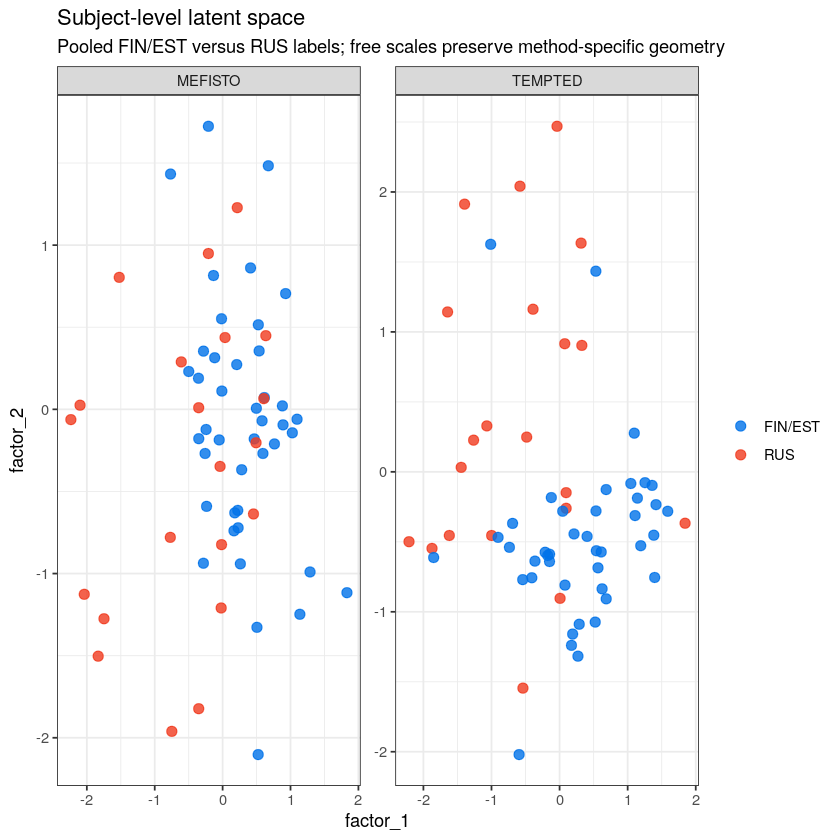

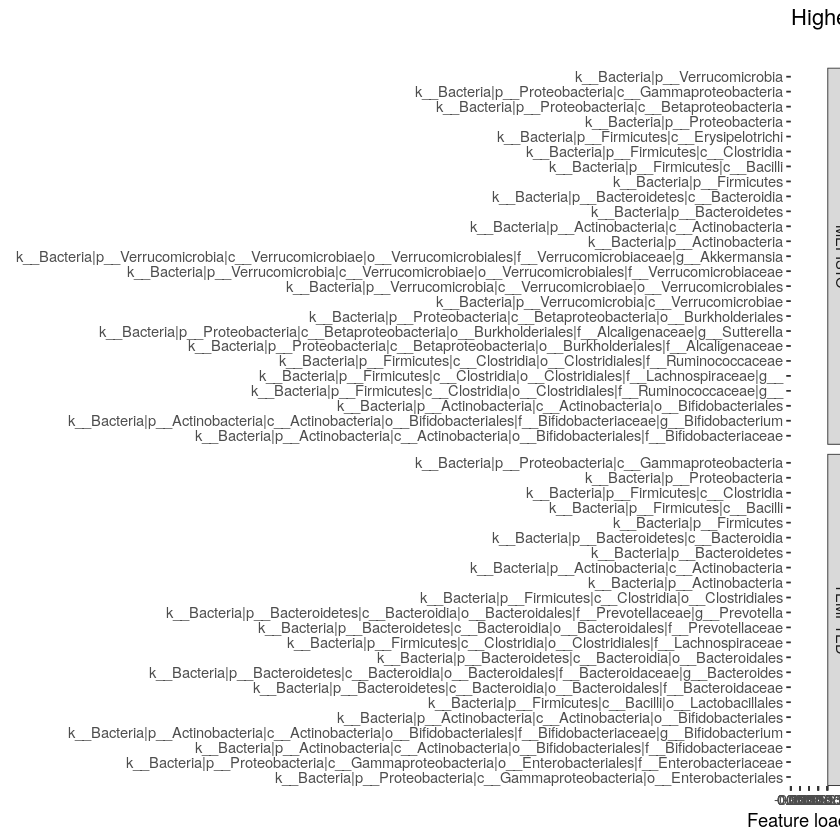

In [3]:
save_plot <- function(name, plot, width = 10, height = 7) {
  ggsave(file.path(figure_output, name), plot, width = width, height = height, dpi = 180)
  print(plot)
}

subject_long <- subject_scores %>%
  pivot_longer(starts_with("factor_"), names_to = "factor", values_to = "score") %>%
  mutate(label = factor(label, levels = GROUP_ORDER))

p_subject_box <- ggplot(subject_long, aes(label, score, fill = label)) +
  geom_boxplot(outlier.alpha = 0.4) +
  facet_grid(method ~ factor, scales = "free_y") +
  scale_fill_manual(values = GROUP_COLORS, drop = FALSE) +
  labs(
    title = "Subject-level scores by phenotype",
    subtitle = "TEMPTED components and MEFISTO factor summaries are shown on their own model scales",
    x = NULL,
    y = "Subject-level score"
  ) +
  theme_bw() +
  theme(legend.position = "none")
save_plot("06_subject_loading_boxplots.png", p_subject_box, 11, 7)

score_wide <- subject_scores %>% mutate(label = factor(label, levels = GROUP_ORDER))
factor_names <- grep("^factor_", names(score_wide), value = TRUE)

if (length(factor_names) >= 2) {
  p_subject_map <- ggplot(score_wide, aes(.data[[factor_names[1]]], .data[[factor_names[2]]], color = label)) +
    geom_point(size = 2.5, alpha = 0.8) +
    facet_wrap(~method, scales = "free") +
    scale_color_manual(values = GROUP_COLORS, drop = FALSE) +
    labs(
      title = "Subject-level latent space",
      subtitle = "Pooled FIN/EST versus RUS labels; free scales preserve method-specific geometry",
      x = factor_names[1],
      y = factor_names[2],
      color = NULL
    ) +
    theme_bw()
  save_plot("06_subject_factor_embedding.png", p_subject_map, 10, 5)
}

loading_long <- feature_loadings %>%
  pivot_longer(starts_with("factor_"), names_to = "factor", values_to = "loading") %>%
  group_by(method, factor) %>%
  slice_max(abs(loading), n = TOP_FEATURES, with_ties = FALSE) %>%
  ungroup() %>%
  mutate(feature_id = reorder(feature_id, loading))

p_loadings <- ggplot(loading_long, aes(loading, feature_id, fill = loading > 0)) +
  geom_col() +
  facet_grid(method ~ factor, scales = "free_y", space = "free_y") +
  labs(title = "Highest-magnitude feature loadings", x = "Feature loading", y = NULL) +
  theme_bw() + theme(legend.position = "none")
save_plot("06_top_feature_loadings.png", p_loadings, 12, 10)

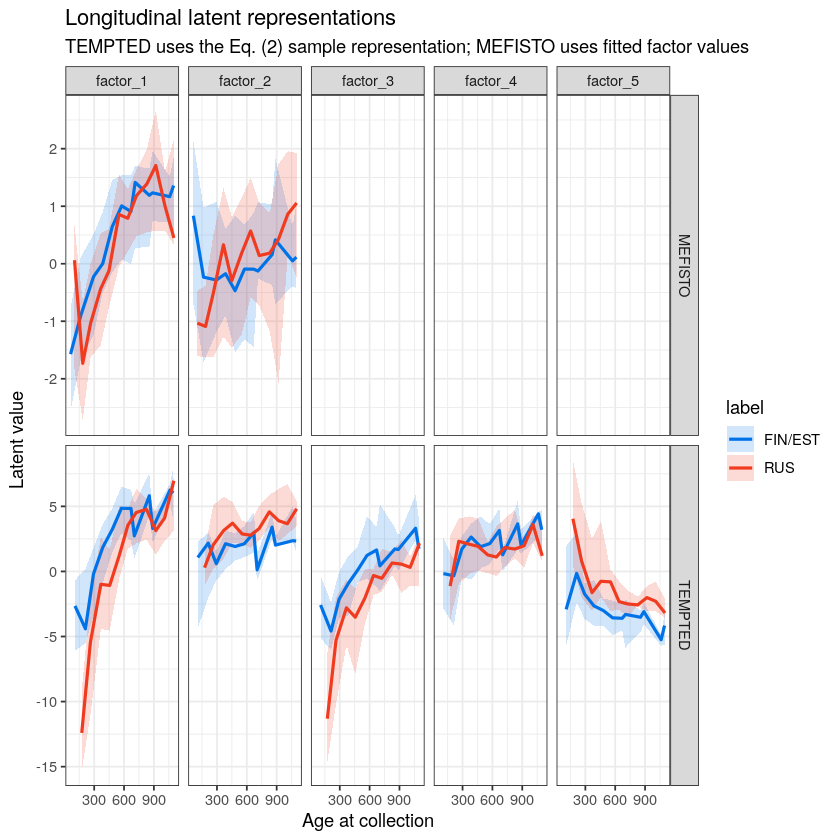

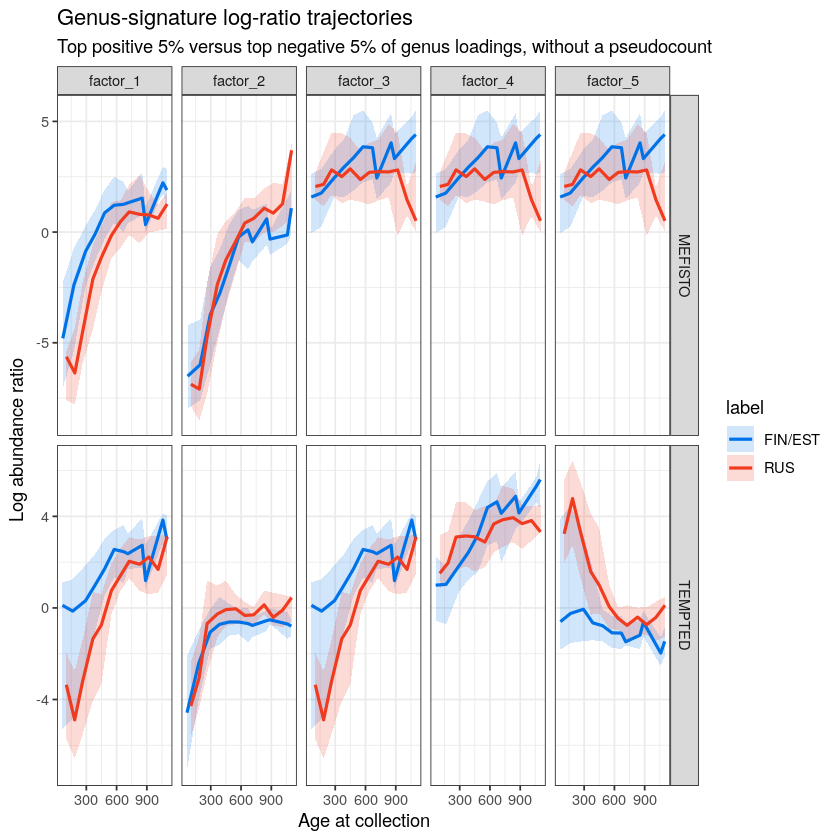

In [4]:
sample_long <- sample_factors %>%
  pivot_longer(starts_with("factor_"), names_to = "factor", values_to = "value") %>%
  filter(is.finite(value), is.finite(time)) %>%
  mutate(label = factor(label, levels = GROUP_ORDER))

trajectory_summary <- sample_long %>%
  mutate(time_bin = cut(time, breaks = 12, include.lowest = TRUE, labels = FALSE)) %>%
  group_by(method, factor, label, time_bin) %>%
  filter(n() >= 3) %>%
  summarise(
    time = median(time, na.rm = TRUE),
    median = median(value, na.rm = TRUE),
    lower = quantile(value, 0.25, na.rm = TRUE),
    upper = quantile(value, 0.75, na.rm = TRUE),
    n = n(),
    .groups = "drop"
  )

p_trajectories <- ggplot(trajectory_summary, aes(time, median, color = label, fill = label)) +
  geom_ribbon(aes(ymin = lower, ymax = upper), alpha = 0.18, color = NA) +
  geom_line(linewidth = 0.9) +
  facet_grid(method ~ factor, scales = "free_y") +
  scale_color_manual(values = GROUP_COLORS, drop = FALSE) +
  scale_fill_manual(values = GROUP_COLORS, drop = FALSE) +
  labs(
    title = "Longitudinal latent representations",
    subtitle = "TEMPTED uses the Eq. (2) sample representation; MEFISTO uses fitted factor values",
    x = "Age at collection",
    y = "Latent value"
  ) +
  theme_bw()
save_plot("06_factor_trajectories.png", p_trajectories, 12, 8)

# Use genus-level features only. Mixing phylum, class, family and genus counts
# would double-count nested taxa and produce a misleading abundance ratio.
genus_loadings <- feature_loadings %>%
  filter(grepl("\\|g__", feature_id), !grepl("\\|s__", feature_id))

relative_abundance <- counts / rowSums(counts)
log_ratio_rows <- list()
row_number <- 1

for (method_name in unique(genus_loadings$method)) {
  method_loadings <- genus_loadings %>% filter(method == method_name)
  factors <- grep("^factor_", names(method_loadings), value = TRUE)

  for (factor_name in factors) {
    ranked <- method_loadings %>% arrange(desc(.data[[factor_name]]))
    n_side <- max(2, ceiling(nrow(ranked) * 0.05))
    positive <- intersect(head(ranked$feature_id, n_side), colnames(relative_abundance))
    negative <- intersect(tail(ranked$feature_id, n_side), colnames(relative_abundance))

    if (!length(positive) || !length(negative)) next

    positive_mass <- rowSums(relative_abundance[, positive, drop = FALSE])
    negative_mass <- rowSums(relative_abundance[, negative, drop = FALSE])
    ratio <- ifelse(positive_mass > 0 & negative_mass > 0, log(positive_mass / negative_mass), NA_real_)

    log_ratio_rows[[row_number]] <- metadata %>%
      transmute(
        method = method_name,
        factor = factor_name,
        sample_id,
        subject_id,
        time,
        label,
        log_ratio = ratio
      )
    row_number <- row_number + 1
  }
}

log_ratios <- bind_rows(log_ratio_rows)

log_ratio_summary <- log_ratios %>%
  filter(is.finite(log_ratio), is.finite(time)) %>%
  mutate(
    label = factor(label, levels = GROUP_ORDER),
    time_bin = cut(time, breaks = 12, include.lowest = TRUE, labels = FALSE)
  ) %>%
  group_by(method, factor, label, time_bin) %>%
  filter(n() >= 3) %>%
  summarise(
    time = median(time, na.rm = TRUE),
    median = median(log_ratio, na.rm = TRUE),
    lower = quantile(log_ratio, 0.25, na.rm = TRUE),
    upper = quantile(log_ratio, 0.75, na.rm = TRUE),
    n = n(),
    .groups = "drop"
  )

p_logratio <- ggplot(log_ratio_summary, aes(time, median, color = label, fill = label)) +
  geom_ribbon(aes(ymin = lower, ymax = upper), alpha = 0.18, color = NA) +
  geom_line(linewidth = 0.9) +
  facet_grid(method ~ factor, scales = "free_y") +
  scale_color_manual(values = GROUP_COLORS, drop = FALSE) +
  scale_fill_manual(values = GROUP_COLORS, drop = FALSE) +
  labs(
    title = "Genus-signature log-ratio trajectories",
    subtitle = "Top positive 5% versus top negative 5% of genus loadings, without a pseudocount",
    x = "Age at collection",
    y = "Log abundance ratio"
  ) +
  theme_bw()
save_plot("06_feature_log_ratio_trajectories.png", p_logratio, 12, 8)

ERROR: Error: object 'output' not found


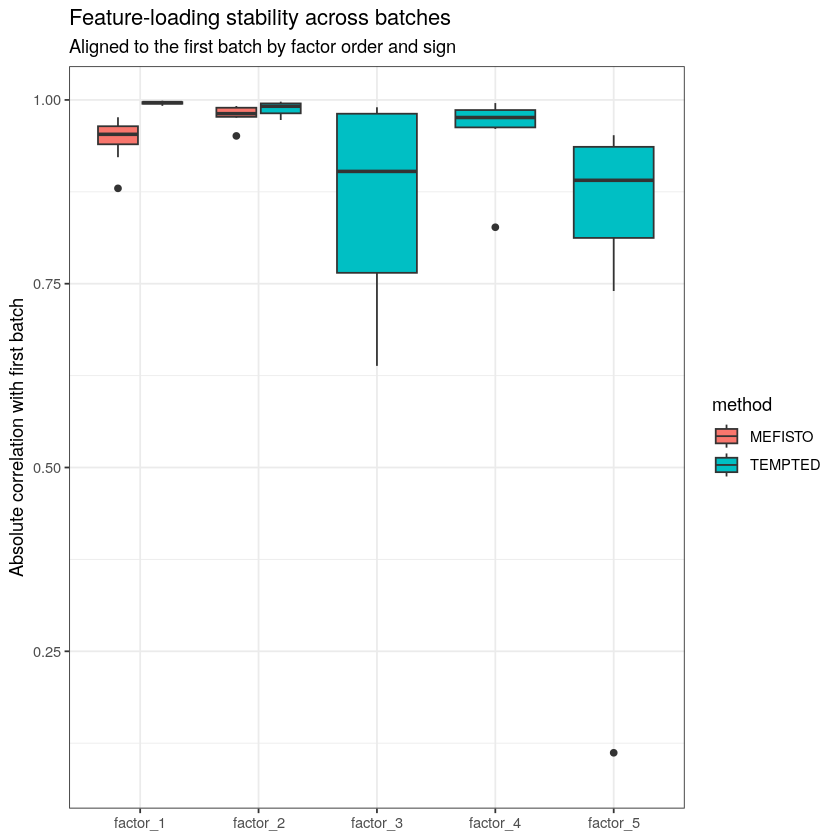

In [5]:
# These are descriptive score summaries, not MEFISTO's learned GP smoothness
# or its model-based percentage of variance explained. Notebook 07 reads the
# actual MEFISTO quantities from model.hdf5.
score_diagnostics <- sample_long %>%
  group_by(method, factor) %>%
  summarise(score_variance = var(value, na.rm = TRUE), .groups = "drop") %>%
  group_by(method) %>%
  mutate(score_variance_fraction = score_variance / sum(score_variance)) %>%
  ungroup()

align_to_reference <- function(reference, current) {
  factors <- intersect(
    grep("^factor_", names(reference), value = TRUE),
    grep("^factor_", names(current), value = TRUE)
  )
  joined <- merge(
    reference[c("feature_id", factors)],
    current[c("feature_id", factors)],
    by = "feature_id",
    suffixes = c("_reference", "_current")
  )

  correlation <- outer(
    factors,
    factors,
    Vectorize(function(reference_factor, current_factor) {
      cor(
        joined[[paste0(reference_factor, "_reference")]],
        joined[[paste0(current_factor, "_current")]],
        use = "complete.obs"
      )
    })
  )

  mapping <- rep(NA_integer_, length(factors))
  used_reference <- rep(FALSE, length(factors))
  used_current <- rep(FALSE, length(factors))

  while (any(is.na(mapping))) {
    remaining_reference <- which(!used_reference)
    remaining_current <- which(!used_current)
    submatrix <- abs(correlation[remaining_reference, remaining_current, drop = FALSE])
    location <- which(submatrix == max(submatrix, na.rm = TRUE), arr.ind = TRUE)[1, ]
    reference_index <- remaining_reference[location[1]]
    current_index <- remaining_current[location[2]]
    mapping[reference_index] <- current_index
    used_reference[reference_index] <- TRUE
    used_current[current_index] <- TRUE
  }

  aligned <- current
  original <- current
  for (reference_index in seq_along(factors)) {
    current_index <- mapping[reference_index]
    sign_value <- ifelse(correlation[reference_index, current_index] < 0, -1, 1)
    aligned[[factors[reference_index]]] <- original[[factors[current_index]]] * sign_value
  }
  aligned
}

loading_stability_rows <- list()
loading_resample_rows <- list()
stability_index <- 1
resample_index <- 1

for (method_name in c("TEMPTED", "MEFISTO")) {
  run_folder <- if (method_name == "TEMPTED") tempted_run else mefisto_run
  reference <- NULL

  for (batch_name in sort(batch_names)) {
    folder <- file.path(run_folder, batch_name)
    current <- try(load_loadings(method_name, folder), silent = TRUE)
    if (inherits(current, "try-error")) next

    if (is.null(reference)) {
      reference <- current
      aligned_current <- current
    } else {
      aligned_current <- align_to_reference(reference, current)
    }

    aligned_current$method <- method_name
    aligned_current$batch <- batch_name
    loading_resample_rows[[resample_index]] <- aligned_current
    resample_index <- resample_index + 1

    if (batch_name == sort(batch_names)[1]) next

    factors <- intersect(
      grep("^factor_", names(reference), value = TRUE),
      grep("^factor_", names(aligned_current), value = TRUE)
    )
    joined <- merge(
      reference,
      aligned_current,
      by = "feature_id",
      suffixes = c("_reference", "_current")
    )

    for (factor_name in factors) {
      correlation <- abs(cor(
        joined[[paste0(factor_name, "_reference")]],
        joined[[paste0(factor_name, "_current")]],
        use = "complete.obs"
      ))
      loading_stability_rows[[stability_index]] <- data.frame(
        method = method_name,
        batch = batch_name,
        factor = factor_name,
        absolute_correlation = correlation
      )
      stability_index <- stability_index + 1
    }
  }
}

loading_stability <- bind_rows(loading_stability_rows)
loading_resamples <- bind_rows(loading_resample_rows)

if (nrow(loading_stability)) {
  lower_limit <- max(0, min(loading_stability$absolute_correlation, na.rm = TRUE) - 0.03)
  p_stability <- ggplot(loading_stability, aes(factor, absolute_correlation, fill = method)) +
    geom_boxplot() +
    coord_cartesian(ylim = c(lower_limit, 1)) +
    labs(
      title = "Feature-loading stability across batches",
      subtitle = "Aligned to the first batch by factor order and sign",
      x = NULL,
      y = "Absolute correlation with first batch"
    ) +
    theme_bw()
  save_plot("06_loading_stability.png", p_stability, 9, 5)
}

write.csv(subject_scores, file.path(data_output, "subject_scores.csv"), row.names = FALSE)
write.csv(sample_factors, file.path(data_output, "sample_factors.csv"), row.names = FALSE)
write.csv(feature_loadings, file.path(data_output, "feature_loadings.csv"), row.names = FALSE)
write.csv(trajectory_summary, file.path(data_output, "trajectory_summary.csv"), row.names = FALSE)
write.csv(log_ratios, file.path(data_output, "log_ratios.csv"), row.names = FALSE)
write.csv(log_ratio_summary, file.path(data_output, "log_ratio_summary.csv"), row.names = FALSE)
write.csv(score_diagnostics, file.path(data_output, "score_diagnostics.csv"), row.names = FALSE)
write.csv(loading_stability, file.path(data_output, "loading_stability.csv"), row.names = FALSE)
write.csv(loading_resamples, file.path(data_output, "loading_resamples.csv"), row.names = FALSE)

cat("Notebook 06 finished. Tables and plots saved to:", output, "
")